# Kontekst biznesowy i pytania analityczne

Churn czyli rezygnacje klientów z usług firm są czymś nieuniknionym co nie znaczy że porządanym.
Celem firm jest powtrzymywanie odpływu klientów (w większości przypadków).
Celem z kolei projektu jest dostarczenie odpowiedzi na pytania:
- kim są osoby odchodzące i czy są jakieś cechy ich wyróżniające?
- jakie znaczenie biznesowe ma ich odejście?

Wymagania szczegółowe wobec projektu:
- model musi być maksymalnie czuły czyli musi poprawnie wskazywac przypadki churn (nawet kosztem fałszywych alarmów w rozsądnej ilości)
- model wskaże najważniejsze cechy za pomocą których definiuje osoby churn co pozwoli na budowę strategii przeciwdziałania churn
- model wskaże prawdopodobieństwo odejścia na podstawie którego można stworzyć segmenty klientów pod względem pilności podjęcia działania

DISCLAIMER:
Teraz po zakończeniu projektu uważam że ten zestaw jest bardzo słaby: nie ma serii czasowych więc nie widzimy zmian np czy dobierali usługi albo czy rezygnowali z całości na raz czy stopniowo, nie znamy deklarowanej przyczyny odejścia, nie znamy kosztów obsługi więc trudno określić jednoznacznie konsekwencje finansowe odejścia, zestaw wygląda na taki prosty, bezreflaksyjny snapshot z bazy danych a nie przygotowany rozmyślnie pod kątem analizy czy treningu itd


# Pobieranie i wczytanie danych

In [ ]:
# Pobieranie danych z API Kaggle poprzez kagglehub
import os
import kagglehub

# Do pobrania zestawu wymagany jest token Kaggle, instrukcja w części Authentication na stronie https://www.kaggle.com/docs/api

kaggle_username = input("Wprowadź swój KAGGLE_USERNAME: ")
kaggle_key = input("Wprowadź swój KAGGLE_KEY: ")

os.environ['KAGGLE_USERNAME'] = kaggle_username
os.environ['KAGGLE_KEY'] = kaggle_key

path = kagglehub.dataset_download("blastchar/telco-customer-churn")


In [2]:
import pandas as pd
df = pd.read_csv(f"{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Feature engineering

In [3]:
# Sprawdzam jakość zestawu danych, zaczynam od wglądu w jego zawartość
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Oraz informacji pozwalających na ocenę jakości danych
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Wnioski i kroki z nimi związane:
- customerID wydaje się być dobrym kandydatem na indeks co pozwoli na śledzenie "losów" każdego z klientów w trakcie procesu analityczno-deweloperskiego oraz na potencjalne unikalne łączenie z innymi źródłami
- Nazwy kolumn są pisane raz z dużej a raz z małej litery co jest uciążliwe w trakcie pisania kodu
- TotalCharges jest także tekstowa choć oczekiwałbym float podobnie jak w przypadku MonthlyCharges
- Żadna z kolumn nie zawiera nulli ale ponieważ 17 kolumn jest tekstowych wiele rekordów może być nieużyteczna bo wystarczy np spacja by "oszukać" format


## Ustalenie indeksu dla df

In [6]:
# Zaczynam od customerID, przed ustawieniem go jako index sprawdzam dwie rzeczy: czy ID są spójne oraz czy są unikalne

# Format customerID wygląda na 4 cyfry-spacja-5liter więc sprawdzam czy są ID odstające od tego formatu
df[~df['customerID'].str.match(r'^\d{4}-[a-zA-Z]{5}$')]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [7]:
# Nie ma, więc spójnośc kluczy jest zachowana, teraz sprawdzam unikalność kluczy
duplicates = df['customerID'][df['customerID'].duplicated()]
duplicates

,customerID


In [8]:
#Oba testy zdane więc ustawiam customerID jako klucz
df = df.set_index('customerID')

## Uspójnienie pisowni nazw kolumn

In [9]:
df.columns = [col[:1].upper() + col[1:] for col in df.columns]

## Analiza formatu i zawartości kolumny TotalCharges

In [10]:
# Teraz dlaczego TotalCharges są tekstem a nie floatem?
df.TotalCharges.value_counts()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
6849.4,1
692.35,1
130.15,1


In [11]:
# Jest 11 spacji które zamieniam na 0 i zmieniam typ kolumny na float
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [12]:
# Sprawdzam teraz jakość kolumn liczbowych TotalCharges, MonthlyCharges i Tenure w połączeniu z Churn
filtered_df = df[(df[['TotalCharges', 'MonthlyCharges', 'Tenure']] < 0.01).any(axis=1)]
filtered_df[['TotalCharges', 'MonthlyCharges', 'Tenure', 'Churn']]

,TotalCharges,MonthlyCharges,Tenure,Churn
customerID,,,,
4472-LVYGI,0.0,52.55,0,No
3115-CZMZD,0.0,20.25,0,No
5709-LVOEQ,0.0,80.85,0,No
4367-NUYAO,0.0,25.75,0,No
1371-DWPAZ,0.0,56.05,0,No
7644-OMVMY,0.0,19.85,0,No
3213-VVOLG,0.0,25.35,0,No
2520-SGTTA,0.0,20.00,0,No
2923-ARZLG,0.0,19.70,0,No


In [14]:
# Jest 11 wierszy które mają 0 w kolumnach TotalCharges i Tenure choć mają wartość w kolumnie MonthlyCharges.
# Wyjaśnieniem może być to że to są nowe umowy przed upływem pierwszego okresu rozliczeniowego albo jakieś umowy które z różnych wzgędów nie weszły w życie.
# 11 wierszy z 7043 to 0,16% więc ich wartość informacyjna niewielka zatem usuwam te wiersze.
df = df[df['Tenure'] != 0]

In [15]:
# Skoro mam czas trwania i miesięczne opłaty to może TotalCharges nie jest w ogóle potrzebna bo jest to prosty iloraz?
# Wyliczenie wartości TotalCharges / Tenure
dfTC= df[['TotalCharges', 'Tenure', 'MonthlyCharges']]
dfTC = dfTC.copy()
dfTC['Calculated_monthly'] = (dfTC['TotalCharges'] / dfTC['Tenure']).round(2)
dfTC[dfTC['Calculated_monthly'] != dfTC['MonthlyCharges']]

,TotalCharges,Tenure,MonthlyCharges,Calculated_monthly
customerID,,,,
5575-GNVDE,1889.50,34,56.95,55.57
3668-QPYBK,108.15,2,53.85,54.08
7795-CFOCW,1840.75,45,42.30,40.91
9237-HQITU,151.65,2,70.70,75.82
9305-CDSKC,820.50,8,99.65,102.56
...,...,...,...,...
6840-RESVB,1990.50,24,84.80,82.94
2234-XADUH,7362.90,72,103.20,102.26
4801-JZAZL,346.45,11,29.60,31.50


In [16]:
# Nie jest więc ją zostawiam. Wyjaśnieniem mogą być zmiany w liczbie usług z których skorzystali klienci albo zmiana cenników

## Analiza jakości kolumn tekstowych

In [17]:
#Teraz czas na analizę struktury pozostałych kolumn tekstowych i sprawdzenie ich jakości


pd.set_option('display.max_colwidth', None)

# Wybieram tylko kolumny o typie object
object_columns = df.select_dtypes(include=['object']).columns

# Zakładam listę do przechowywania wyników
unique_counts = []

# Iteruję tylko przez kolumny object
for column in object_columns:
    counts = df[column].value_counts()  # Zliczanie unikalnych wartości
    unique_counts.append({
        'Column': column,
        'Unique Values': counts.index.tolist(),
        'Counts': counts.tolist()
    })

# Tworzę nową ramkę danych z wyników i ją wyświetlam
result_df = pd.DataFrame(unique_counts)
result_df

,Column,Unique Values,Counts
0,Gender,"[Male, Female]","[3549, 3483]"
1,Partner,"[No, Yes]","[3639, 3393]"
2,Dependents,"[No, Yes]","[4933, 2099]"
3,PhoneService,"[Yes, No]","[6352, 680]"
4,MultipleLines,"[No, Yes, No phone service]","[3385, 2967, 680]"
5,InternetService,"[Fiber optic, DSL, No]","[3096, 2416, 1520]"
6,OnlineSecurity,"[No, Yes, No internet service]","[3497, 2015, 1520]"
7,OnlineBackup,"[No, Yes, No internet service]","[3087, 2425, 1520]"
8,DeviceProtection,"[No, Yes, No internet service]","[3094, 2418, 1520]"
9,TechSupport,"[No, Yes, No internet service]","[3472, 2040, 1520]"


In [18]:
# Żadna z kolumn nie zawiera jakichś śmieciowych danych typu spacja
# Żadna nie zawiera skrajnie niezbalansowanych wartości, najgorzej wygląda PhoneService
# Uważam że zestaw jest wystarczającej jakości by sprawdzić jego wartość w EDA

# EDA



In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   Tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null 

Ogólne informacje o churn oraz analiza korelacji

19 cech dzielę na 4 grupy powiązane tematycznie:
- Metryczka: 'Gender', 'SeniorCitizen', 'Partner', 'Dependents'
- Opłaty i czas trwania: 'MonthlyCharges', 'TotalCharges', 'Tenure"
- Korzystanie z usług: 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
- Sprawy formalne: 'Contract', 'PaperlessBilling', 'PaymentMethod',
       

## Churn ogólnie i korelacje

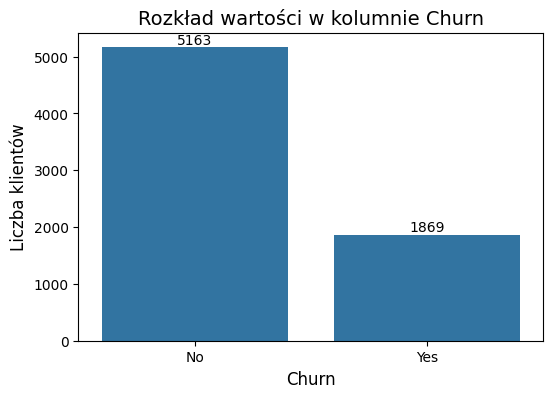

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obliczanie liczebności
value_counts = df['Churn'].value_counts()

# Tworzenie wykresu
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df)

# Dodawanie liczebności na słupkach
for p, count in zip(ax.patches, value_counts):
    ax.annotate(f'{count}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

# Dodanie tytułu i etykiet
plt.title('Rozkład wartości w kolumnie Churn', fontsize=14)
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Liczba klientów', fontsize=12)
plt.show()


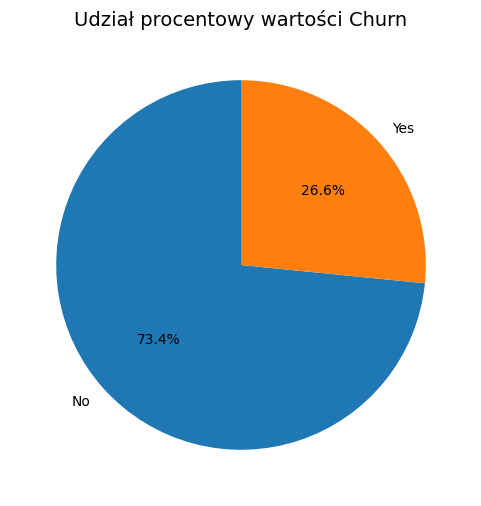

In [21]:
# Procentowy rozkład Churn
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

# Wykres kołowy
plt.figure(figsize=(6, 6))
churn_percentage.plot.pie(autopct='%1.1f%%', startangle=90, colors=['#1f77b4', '#ff7f0e'])
plt.title('Udział procentowy wartości Churn', fontsize=14)
plt.ylabel('')
plt.show()


In [23]:
#Badam korelacje z innymi cechami

# One-hot encoding
df_dum = pd.get_dummies(df)

# Obliczanie korelacji
df_corr = df_dum.corr()

# Filtracja dla kolumny 'Churn_Yes' i wykluczenie 'Churn_Yes' oraz 'Churn_No'
filtered_corr = df_corr['Churn_Yes'].drop(['Churn_Yes', 'Churn_No'])

# Zachowanie wartości korelacji spoza zakresu (-0.2, 0.2)
filtered_corr = filtered_corr[filtered_corr.abs() > 0.2]

# Sortowanie od najwyższych wartości korelacji
filtered_corr = filtered_corr.sort_values(ascending=False)

filtered_corr


,Churn_Yes
Contract_Month-to-month,0.404565
OnlineSecurity_No,0.342235
TechSupport_No,0.336877
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
OnlineBackup_No,0.267595
DeviceProtection_No,0.252056
InternetService_No,-0.227578
OnlineSecurity_No internet service,-0.227578
OnlineBackup_No internet service,-0.227578


## Analiza metryczki

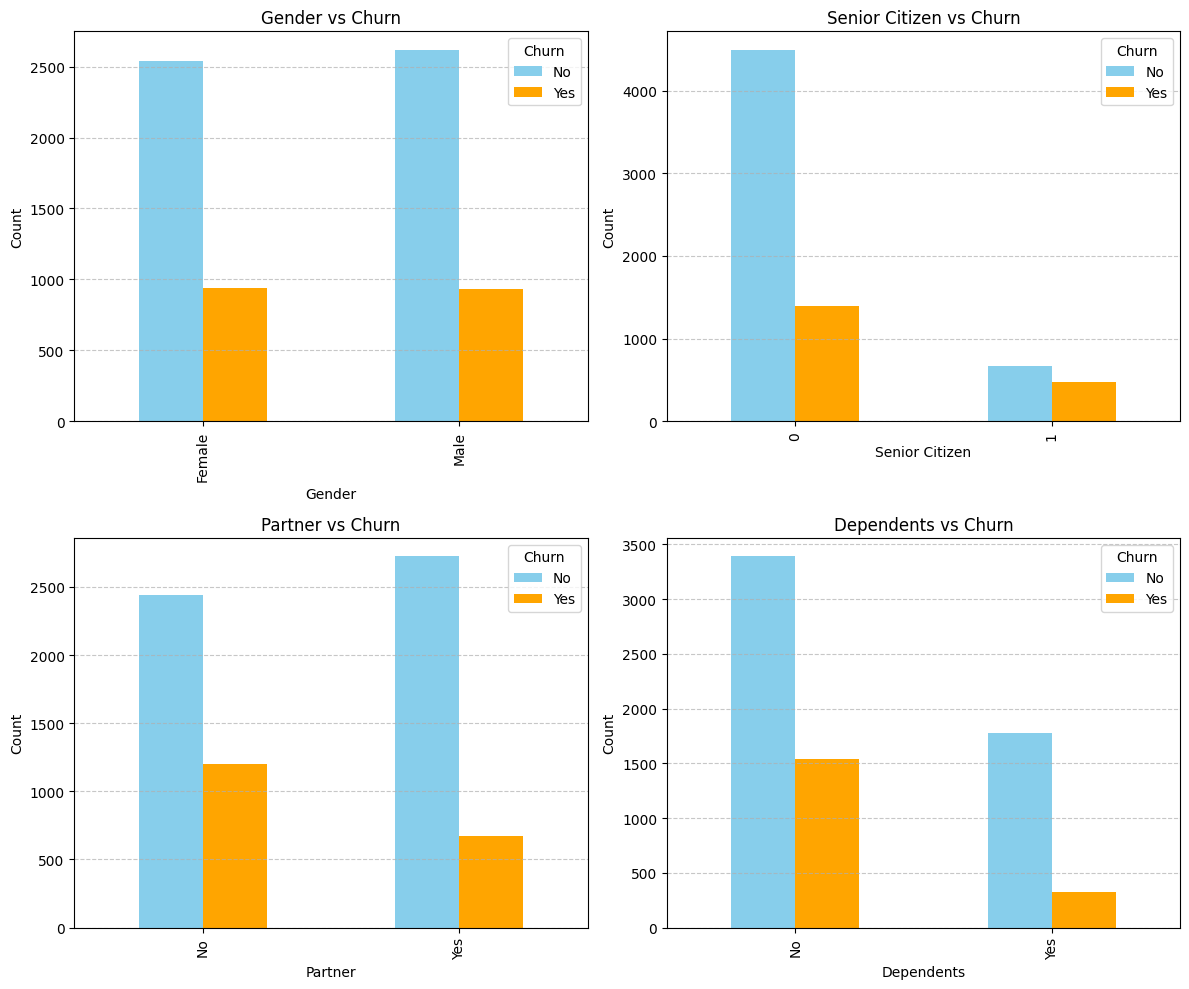

In [24]:
import matplotlib.pyplot as plt

# Grupowanie danych i agregacja dla każdej kolumny względem Churn
gender_churn = df.groupby(['Gender', 'Churn']).size().unstack(fill_value=0)
senior_churn = df.groupby(['SeniorCitizen', 'Churn']).size().unstack(fill_value=0)
partner_churn = df.groupby(['Partner', 'Churn']).size().unstack(fill_value=0)
dependents_churn = df.groupby(['Dependents', 'Churn']).size().unstack(fill_value=0)

# Tworzenie wykresów w układzie 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gender vs Churn
gender_churn.plot(kind='bar', ax=axes[0, 0], color=['skyblue', 'orange'])
axes[0, 0].set_title('Gender vs Churn')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(title='Churn')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Senior Citizen vs Churn
senior_churn.plot(kind='bar', ax=axes[0, 1], color=['skyblue', 'orange'])
axes[0, 1].set_title('Senior Citizen vs Churn')
axes[0, 1].set_xlabel('Senior Citizen')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(title='Churn')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Partner vs Churn
partner_churn.plot(kind='bar', ax=axes[1, 0], color=['skyblue', 'orange'])
axes[1, 0].set_title('Partner vs Churn')
axes[1, 0].set_xlabel('Partner')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(title='Churn')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Dependents vs Churn
dependents_churn.plot(kind='bar', ax=axes[1, 1], color=['skyblue', 'orange'])
axes[1, 1].set_title('Dependents vs Churn')
axes[1, 1].set_xlabel('Dependents')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Churn')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()


Wnioski:
- płeć nie ma znaczenie dla wskazania kto odejdzie
- pozostałe 3 wykresy podpowiadają szybki ale błędny wniosek że wypowiadają osoby młode (nie senior), bez partnera i bez osób na utrzymaniu
- zwraca bowiem moją uwagę to że seniorów ogólnie jest mało ale aż 40% odchodzi, analizuję więc tą cechę głębiej

In [25]:
#Ilu seniorów rezygnuje z usług

# Filtr seniorów
senior_citizens = df[df['SeniorCitizen'] == 1]

# Liczba seniorów, którzy odeszli
churn_yes_count = senior_citizens[senior_citizens['Churn'] == 'Yes'].shape[0]

# Całkowita liczba seniorów
total_senior_citizens = senior_citizens.shape[0]

# Procent seniorów, którzy odeszli
perc_seniors_churn = (churn_yes_count / total_senior_citizens) * 100
print(f"Procent seniorów, którzy odeszli: {perc_seniors_churn:.2f}%")


Procent seniorów, którzy odeszli: 41.68%


In [26]:
# Filtr klientów, którzy odeszli
churned_customers = df[df['Churn'] == 'Yes']

# Liczba seniorów wśród klientów, którzy odeszli
senior_churn = churned_customers[churned_customers['SeniorCitizen'] == 1].shape[0]

# Całkowita liczba klientów, którzy odeszli
total_churn = churned_customers.shape[0]

# Udział seniorów wśród klientów, którzy odeszli
churn_senior_share = (senior_churn / total_churn) * 100
print(f"Udział seniorów wśród klientów, którzy odeszli: {churn_senior_share:.2f}%")


Udział seniorów wśród klientów, którzy odeszli: 25.47%


In [27]:
#Czy ma to znaczenie finansowe?
SeniorCharges = df.groupby(['SeniorCitizen','Churn'])[['Tenure', 'MonthlyCharges']].agg(['mean'])
SeniorCharges

Tenure MonthlyCharges
                          mean           mean
SeniorCitizen Churn                          
0             No     36.996887      58.660196
              Yes    16.935391      72.298098
1             No     42.060060      79.182057
              Yes    21.033613      80.713445

Tak bo seniorzy zostają średnio na dłużej i płacą wyższe opłaty miesięczne
Smutna rzeczywistość jest taka że pewnie naturalnie przeprowadzają się do innego świata gdzie Internet nie dociera. Brak w danych informacji o przyczynach odejścia oraz czy np partner seniora przejął jego umowę itd

## Analiza opłat i czasu trwania

In [28]:
# Obliczanie statystyk opisowych dla Churn = 'Yes'
churn_yes_describe = df[df['Churn'] == 'Yes'][['Tenure', 'MonthlyCharges', 'TotalCharges']].describe()
churn_yes_describe

,Tenure,MonthlyCharges,TotalCharges
count,1869.000000,1869.000000,1869.000000
mean,17.979133,74.441332,1531.796094
std,19.531123,24.666053,1890.822994
min,1.000000,18.850000,18.850000
25%,2.000000,56.150000,134.500000
50%,10.000000,79.650000,703.550000
75%,29.000000,94.200000,2331.300000
max,72.000000,118.350000,8684.800000


In [29]:
# Obliczanie statystyk opisowych dla Churn = 'No'
churn_no_describe = df[df['Churn'] == 'No'][['Tenure', 'MonthlyCharges', 'TotalCharges']].describe()
churn_no_describe


,Tenure,MonthlyCharges,TotalCharges
count,5163.00000,5163.000000,5163.000000
mean,37.65001,61.307408,2555.344141
std,24.07694,31.094557,2329.456984
min,1.00000,18.250000,18.800000
25%,15.00000,25.100000,577.825000
50%,38.00000,64.450000,1683.600000
75%,61.00000,88.475000,4264.125000
max,72.00000,118.750000,8672.450000


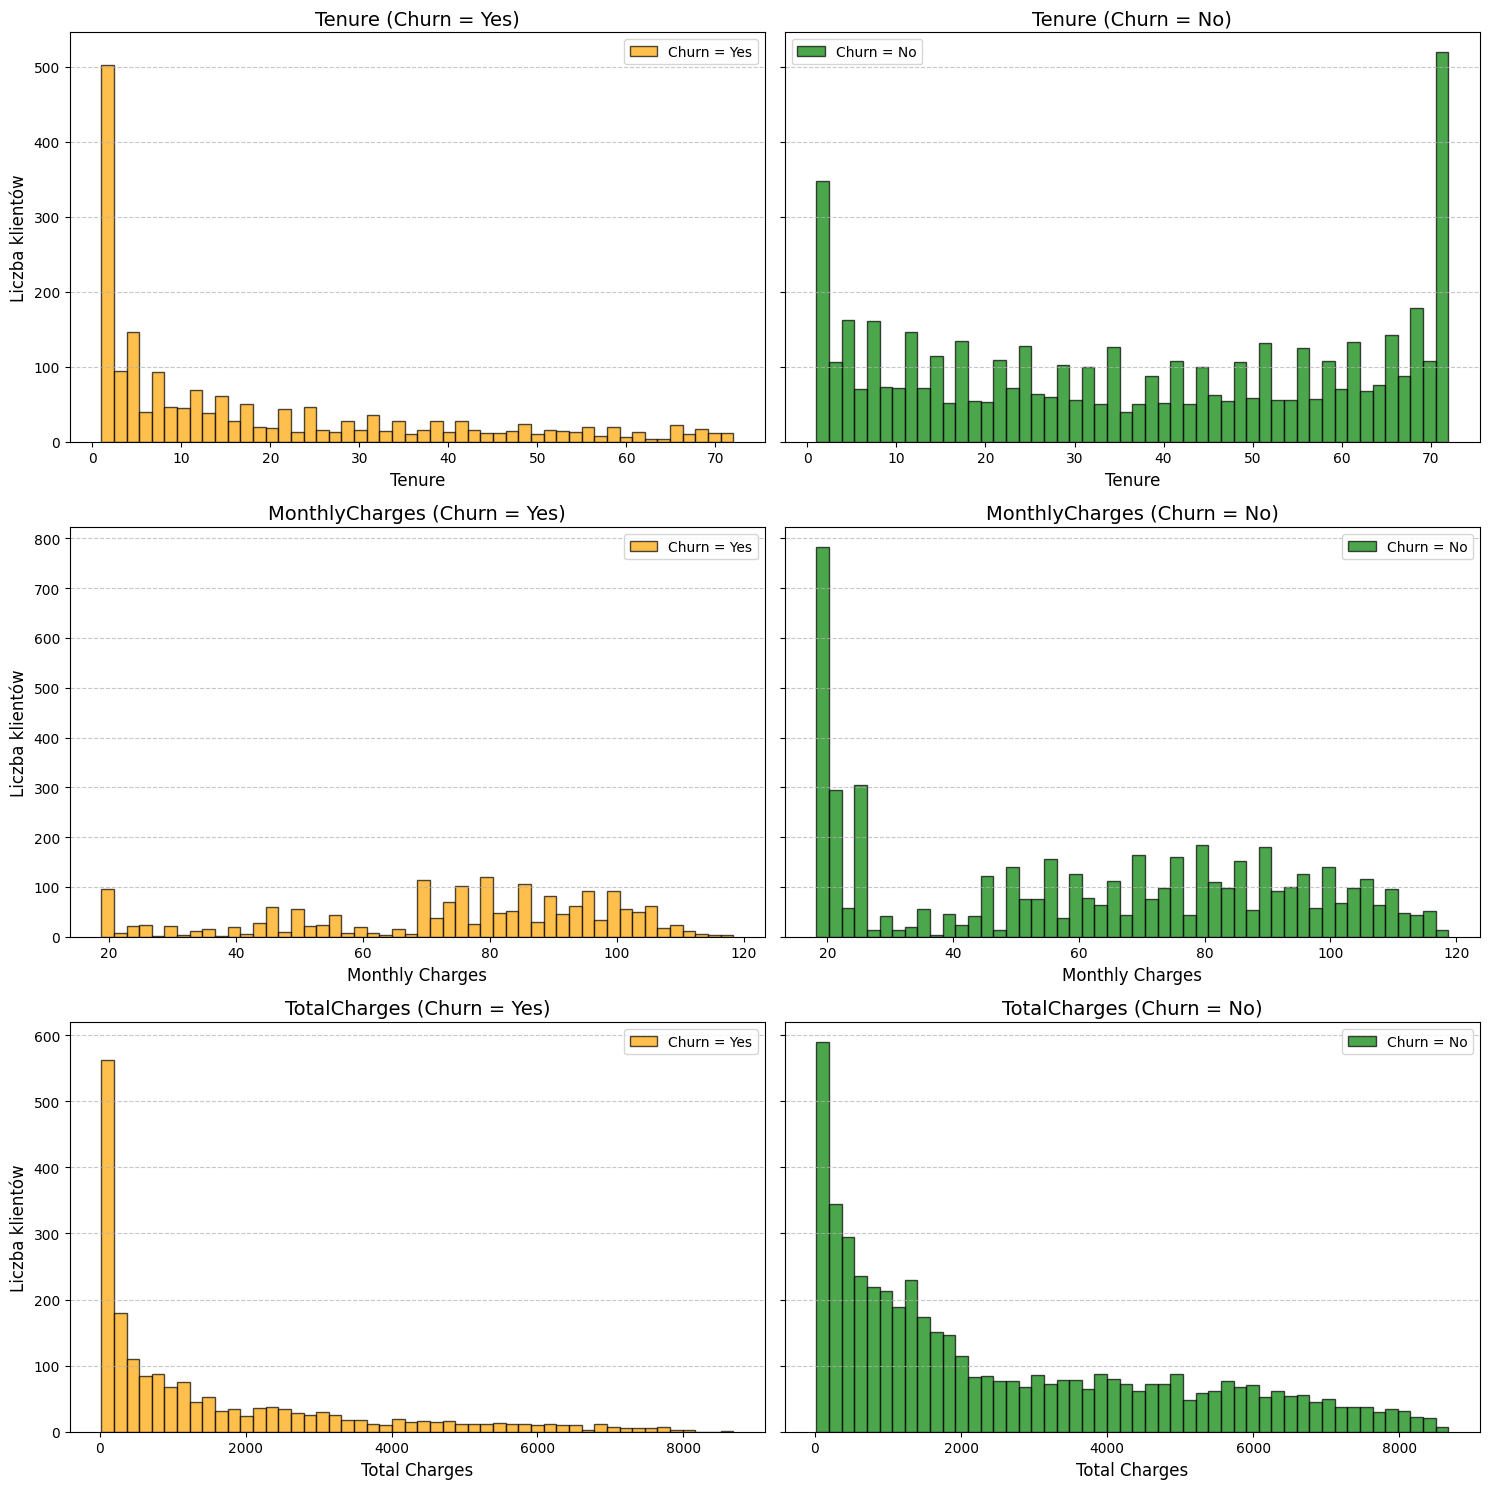

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Konwersja TotalCharges na wartości liczbowe
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Filtrujemy dane dla Churn = 'Yes' i 'No'
tenure_churn_yes = df[df['Churn'] == 'Yes']['Tenure']
tenure_churn_no = df[df['Churn'] == 'No']['Tenure']

monthly_charges_churn_yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
monthly_charges_churn_no = df[df['Churn'] == 'No']['MonthlyCharges']

total_charges_churn_yes = df[df['Churn'] == 'Yes']['TotalCharges'].dropna()
total_charges_churn_no = df[df['Churn'] == 'No']['TotalCharges'].dropna()

# Tworzymy wykresy
fig, axes = plt.subplots(3, 2, figsize=(15, 15), sharey='row')

# Histogram dla Tenure
axes[0, 0].hist(tenure_churn_yes, bins=50, edgecolor='k', alpha=0.7, color='orange', label='Churn = Yes')
axes[0, 1].hist(tenure_churn_no, bins=50, edgecolor='k', alpha=0.7, color='green', label='Churn = No')
axes[0, 0].set_title('Tenure (Churn = Yes)', fontsize=14)
axes[0, 1].set_title('Tenure (Churn = No)', fontsize=14)

# Histogram dla MonthlyCharges
axes[1, 0].hist(monthly_charges_churn_yes, bins=50, edgecolor='k', alpha=0.7, color='orange', label='Churn = Yes')
axes[1, 1].hist(monthly_charges_churn_no, bins=50, edgecolor='k', alpha=0.7, color='green', label='Churn = No')
axes[1, 0].set_title('MonthlyCharges (Churn = Yes)', fontsize=14)
axes[1, 1].set_title('MonthlyCharges (Churn = No)', fontsize=14)

# Histogram dla TotalCharges
axes[2, 0].hist(total_charges_churn_yes, bins=50, edgecolor='k', alpha=0.7, color='orange', label='Churn = Yes')
axes[2, 1].hist(total_charges_churn_no, bins=50, edgecolor='k', alpha=0.7, color='green', label='Churn = No')
axes[2, 0].set_title('TotalCharges (Churn = Yes)', fontsize=14)
axes[2, 1].set_title('TotalCharges (Churn = No)', fontsize=14)

# Dodanie osi Y, X i legendy
for i, feature in enumerate(['Tenure', 'Monthly Charges', 'Total Charges']):
    axes[i, 0].set_ylabel('Liczba klientów', fontsize=12)
    for j in range(2):
        axes[i, j].set_xlabel(feature, fontsize=12)
        axes[i, j].grid(axis='y', linestyle='--', alpha=0.7)
        axes[i, j].legend()

# Dopasowanie układu i wyświetlenie wykresów
plt.tight_layout()
plt.show()


Wnioski:
- Osoby odchodzące wnoszą większe opłaty
- Aż połowa z nich rezygnuje po pierwszym okresie
- Wśród osóbo zostających też jest bardzo dużo krótkich okresów - prawdopodobnie dane to snaphot bazy klientów
- Powtarzający się wzór zwiększonych tenure co 2-3 miesiące świadczy być może o prowadzonych cyklicznie akcjach promocyjnych

## Analiza korzystania z usług i churn

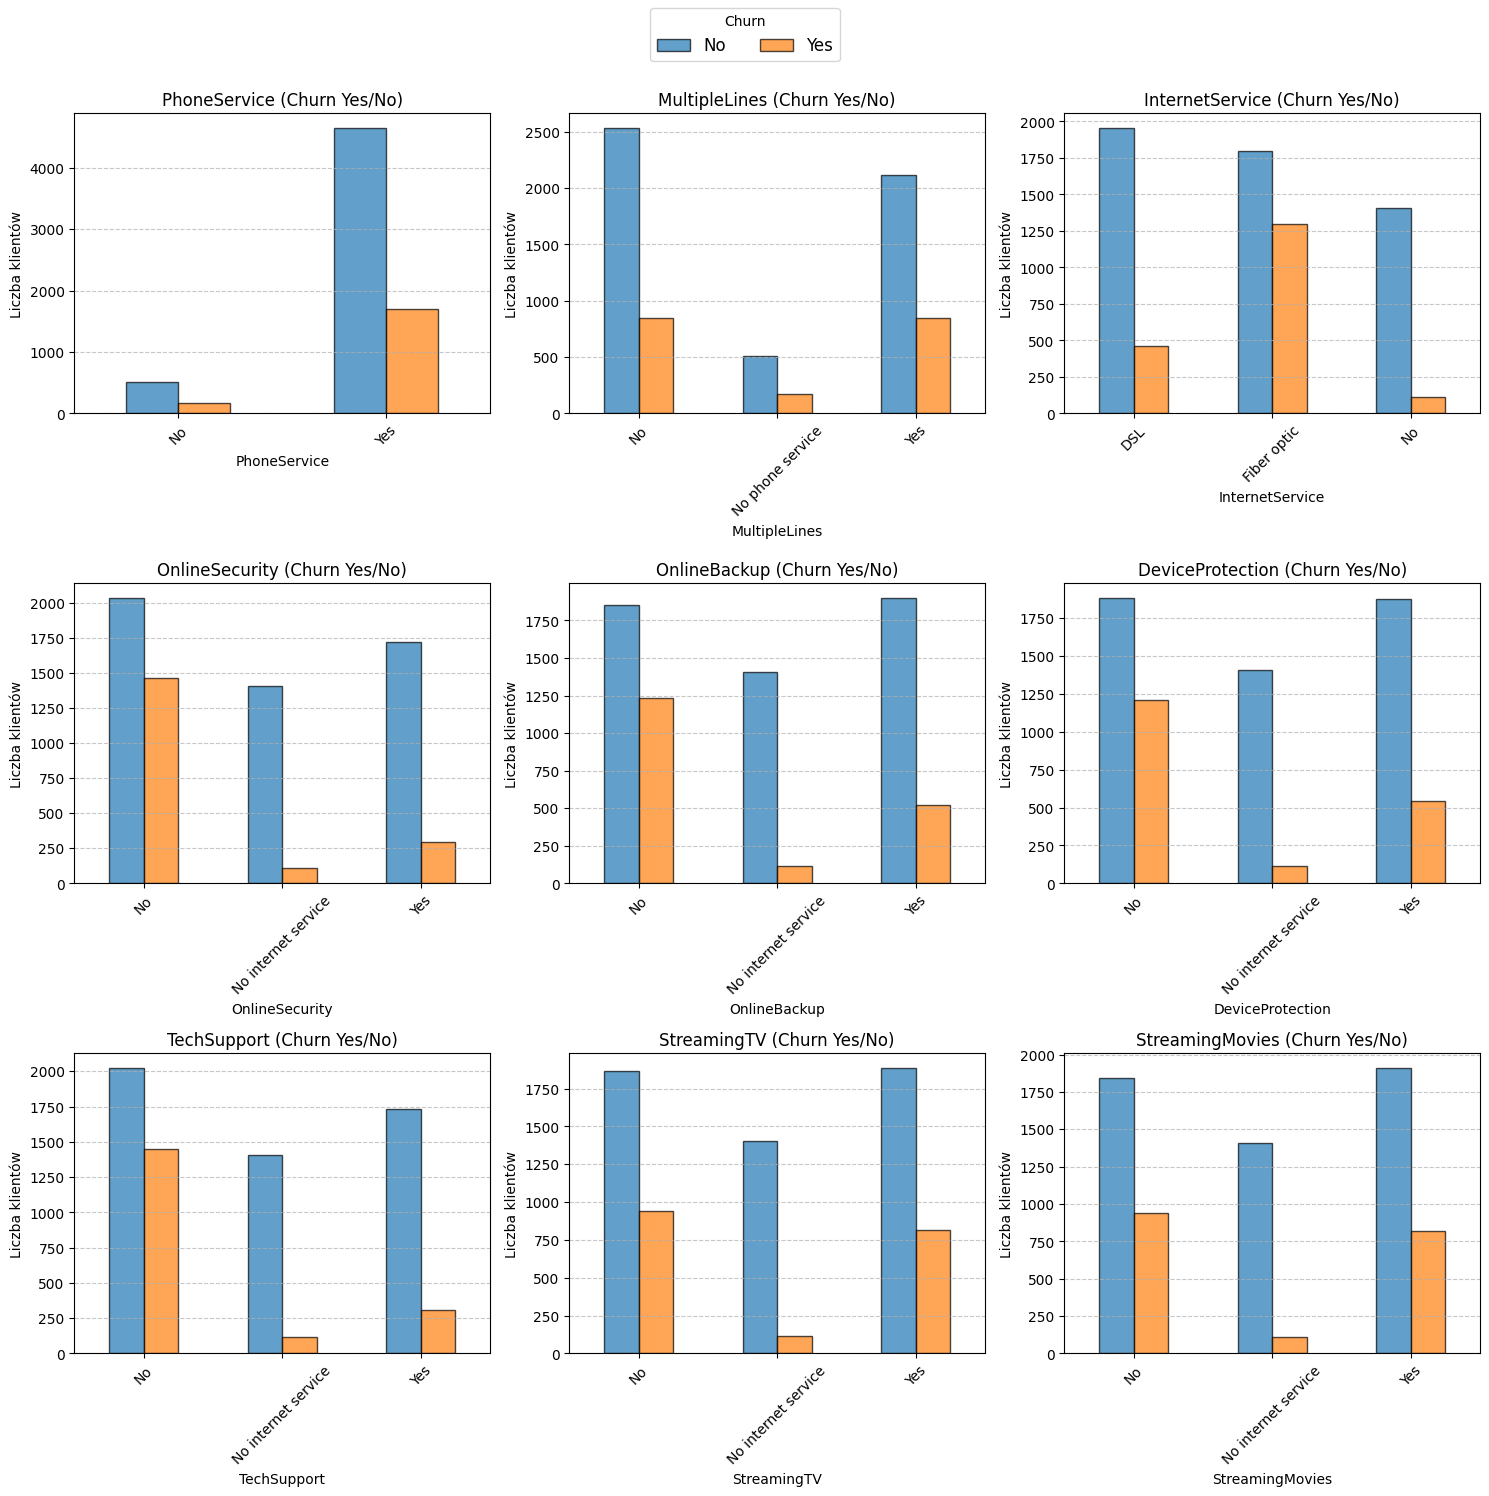

In [31]:
# Kolumny do analizy
columns = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Ustawienia dla siatki 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Flatten listy osi, aby iterować przez nią
axes = axes.flatten()

# Tworzymy wykresy
for i, column in enumerate(columns):
    # Grupowanie danych i zliczanie wartości dla Churn Yes/No
    churn_counts = df.groupby([column, 'Churn']).size().unstack()

    # Tworzymy wykres słupkowy na odpowiedniej osi
    churn_counts.plot(kind='bar', ax=axes[i], edgecolor='k', alpha=0.7, legend=False)
    axes[i].set_title(f'{column} (Churn Yes/No)', fontsize=12)
    axes[i].set_xlabel(column, fontsize=10)
    axes[i].set_ylabel('Liczba klientów', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].tick_params(axis='x', rotation=45)

# Dodanie wspólnej legendy
fig.legend(['No', 'Yes'], loc='upper center', ncol=2, fontsize=12, title='Churn')
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Dostosowanie układu z przestrzenią na legendę
plt.show()


Wnioski:
- korzystanie z FiberOptic w Internet oraz NIE korzystanie z usług dodatkowych wydają się silnymi wskaźnikami osób odchodzących

## Analiza spraw administracyjnych

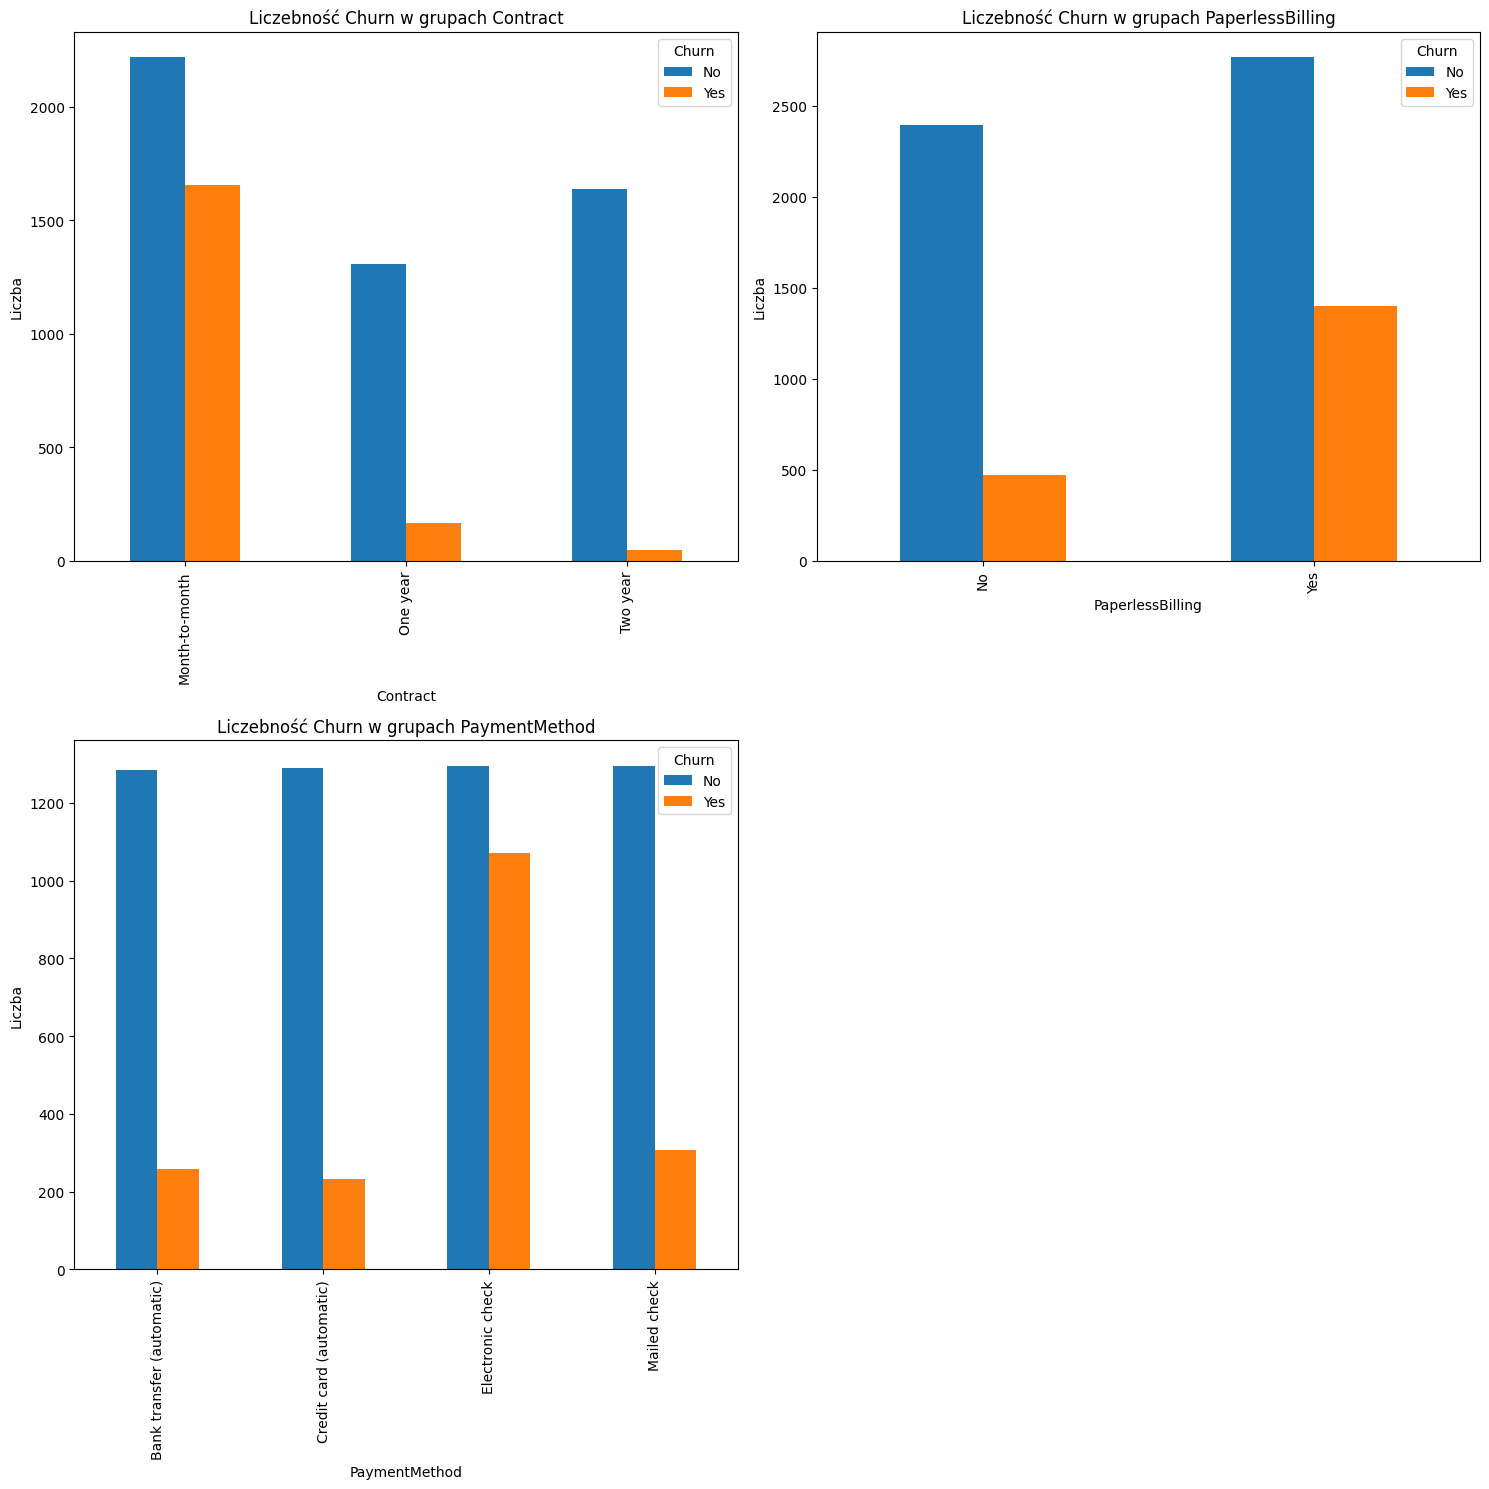

In [32]:
# Lista kolumn do analizy
columns = ['Contract', 'PaperlessBilling', 'PaymentMethod']

# Stworzenie wykresów liczebności
fig, axes = plt.subplots(2, 2, figsize=(15, 15))  # 2x2 dla lepszego układu
axes = axes.flatten()

for i, col in enumerate(columns):  # Iterujemy po całej liście columns
    df.groupby([col, 'Churn']).size().unstack().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Liczebność Churn w grupach {col}')
    axes[i].set_ylabel('Liczba')
    axes[i].set_xlabel(col)
    axes[i].legend(title='Churn', labels=['No', 'Yes'])

# Ukrywanie pustych osi (dla 2x2 layoutu z 3 wykresami)
if len(columns) < len(axes):
    for j in range(len(columns), len(axes)):
        axes[j].axis('off')

# Poprawienie układu
plt.tight_layout()
plt.show()


Wnioski:
- klienci odchodzący są bardzo elektroniczni: chcą faktur w wersji elektronicznej a i sam płacą takimi czekami
- i wybierają umowy płatne co miesiąc (i nie automatycznie opłacane)
- wygląda na nastawienie bardzo tu i teraz

# Trenowanie modelu

## Przygotowanie danych

In [33]:
# Konwersja zmiennych tekstowych na typ category
categorical_columns = df.select_dtypes(include=['object']).columns
df[categorical_columns] = df[categorical_columns].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Gender            7032 non-null   category
 1   SeniorCitizen     7032 non-null   int64   
 2   Partner           7032 non-null   category
 3   Dependents        7032 non-null   category
 4   Tenure            7032 non-null   int64   
 5   PhoneService      7032 non-null   category
 6   MultipleLines     7032 non-null   category
 7   InternetService   7032 non-null   category
 8   OnlineSecurity    7032 non-null   category
 9   OnlineBackup      7032 non-null   category
 10  DeviceProtection  7032 non-null   category
 11  TechSupport       7032 non-null   category
 12  StreamingTV       7032 non-null   category
 13  StreamingMovies   7032 non-null   category
 14  Contract          7032 non-null   category
 15  PaperlessBilling  7032 non-null   category
 16  PaymentMethod 

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score,classification_report
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

In [35]:
# Zakodowanie Churn
df['Churn'] = LabelEncoder().fit_transform(df['Churn'])

In [36]:
# Podział na zestaw cech uczących i target
X = df.drop('Churn', axis=1)
y = df['Churn']


In [37]:
# Podział na zbiór treningowy i testowy

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
# Zestway przygotowane
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 19), (1407, 19), (5625,), (1407,))

## Trening modelu bazowego (czysty XGboost)

Recall on Test Set: 0.48
Accuracy on Training Set: 0.95
Accuracy on Test Set: 0.77

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.59      0.48      0.53       374

    accuracy                           0.77      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.77      0.77      1407



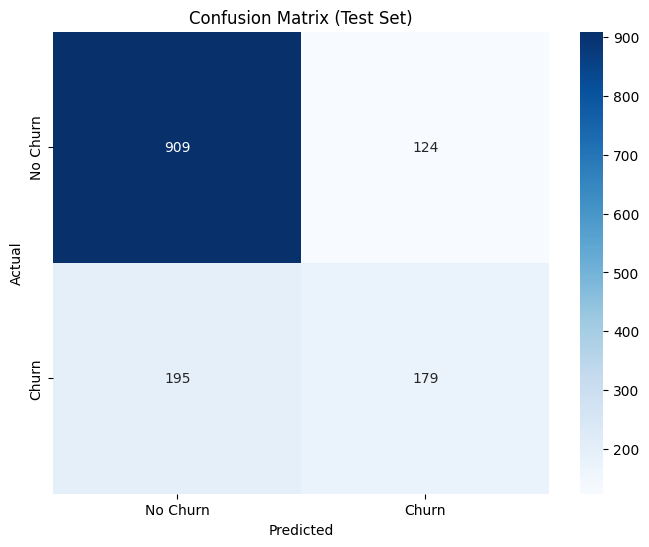

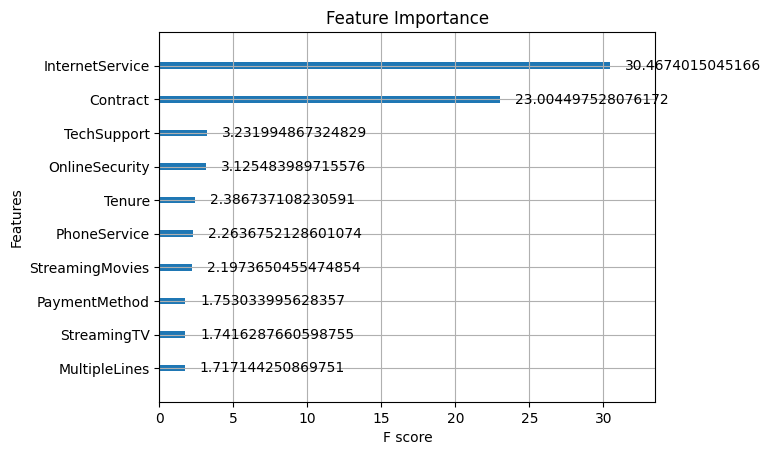

In [39]:
# Specyfikacja modelu XGBoost z wbudowaną obsługą zmiennych kategorycznych
model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_estimators=100,
    tree_method='hist',
    enable_categorical=True
)

# Trening modelu

model.fit(X_train, y_train)

# Predykcje na zbiorze treningowym i testowym
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Ocena wyników: recall
test_recall = recall_score(y_test, y_test_pred)
print(f"Recall on Test Set: {test_recall:.2f}")

# Ocena wyników: accuracy treningowy
train_accuracy = accuracy_score(y_train, y_train_pred)

# Ocena wyników: accuracy testowy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Macierz konfuzji
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Wyświetlenie wyników
print(f"Accuracy on Training Set: {train_accuracy:.2f}")
print(f"Accuracy on Test Set: {test_accuracy:.2f}\n")
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Wizualizacja macierzy konfuzji
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# Ważność cech
xgb.plot_importance(model, max_num_features=10, importance_type='gain', title='Feature Importance')
plt.show()


## Trening modelu z optymalizacją

In [ ]:
pip install optuna

[I 2024-12-05 11:53:18,173] A new study created in memory with name: no-name-d6ac46e9-9e72-4ad0-a250-42c6d4f7efa5
[I 2024-12-05 11:53:29,533] Trial 0 finished with value: 0.7677925764505168 and parameters: {'scale_pos_weight': 2.6024868533807815, 'n_estimators': 267, 'max_depth': 75, 'learning_rate': 0.005011070128804495, 'min_child_weight': 9.590448158973322, 'reg_alpha': 3.250616426204215, 'reg_lambda': 6.350625759036434, 'subsample': 0.7908600135237442, 'colsample_bytree': 0.5217542007911397}. Best is trial 0 with value: 0.7677925764505168.
[I 2024-12-05 11:53:34,131] Trial 1 finished with value: 0.8186291235967943 and parameters: {'scale_pos_weight': 2.9662745890576456, 'n_estimators': 338, 'max_depth': 91, 'learning_rate': 0.006320538325515345, 'min_child_weight': 8.445306139949318, 'reg_alpha': 9.198984389897785, 'reg_lambda': 8.704862287166424, 'subsample': 0.9453640056240482, 'colsample_bytree': 0.5035716798217991}. Best is trial 1 with value: 0.8186291235967943.
[I 2024-12-05 


Best Hyperparameters: {'scale_pos_weight': 2.960499754522043, 'n_estimators': 264, 'max_depth': 39, 'learning_rate': 0.0017092119931858025, 'min_child_weight': 6.931077981239893, 'reg_alpha': 6.670513148430169, 'reg_lambda': 7.822467496777729, 'subsample': 0.5836283841603356, 'colsample_bytree': 0.5337435820778236}
Recall on Test Set: 0.83
Accuracy on Training Set: 0.75
Accuracy on Test Set: 0.71

Classification Report (Test Set):


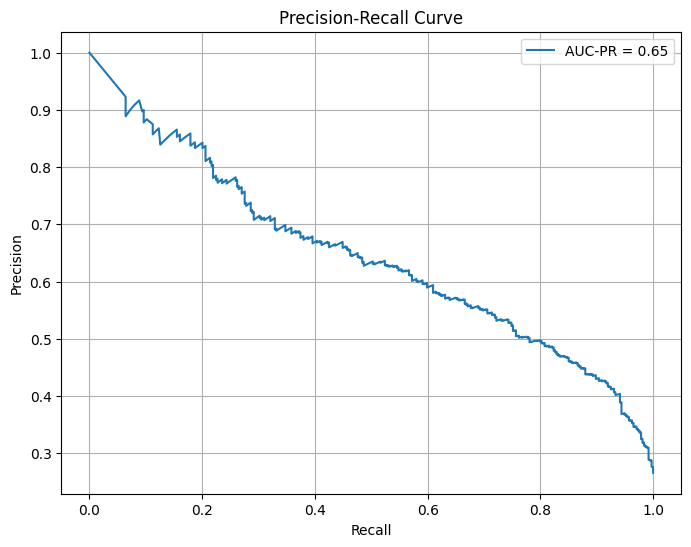

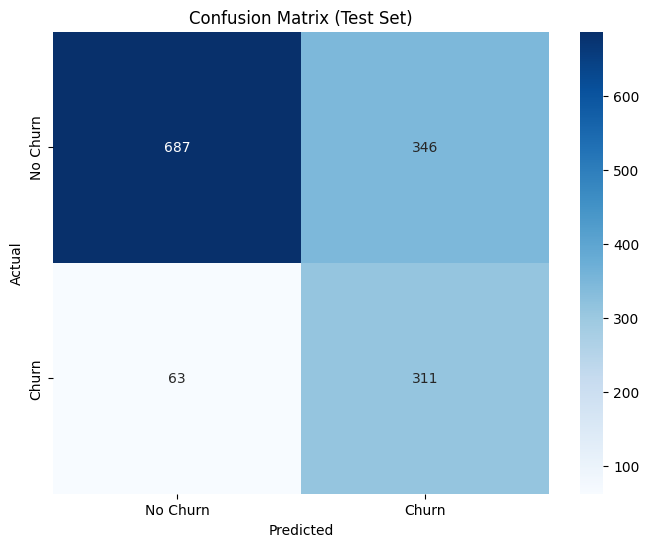

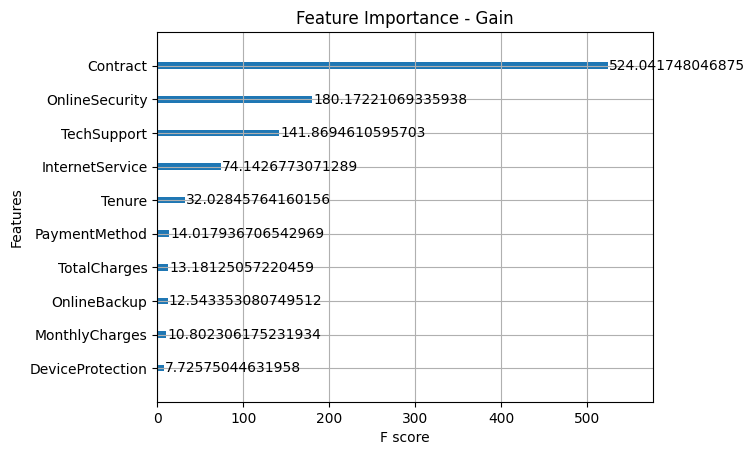

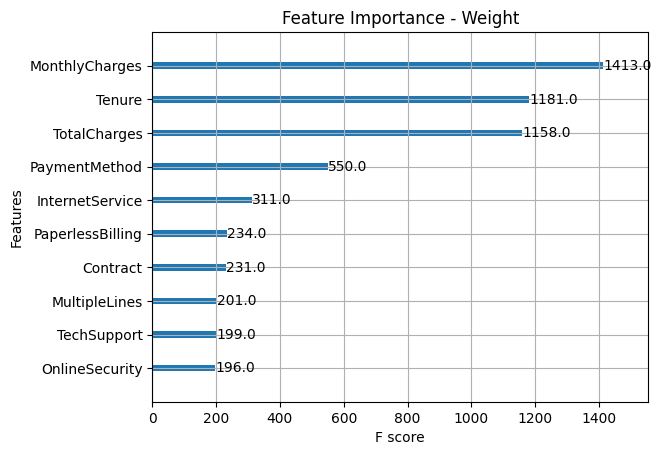

In [44]:
import optuna
from sklearn.metrics import recall_score, precision_recall_curve, auc, confusion_matrix,classification_report
import numpy as np
from sklearn.model_selection import StratifiedKFold

# Funkcja celu dla Optuna
def objective(trial):
    # Hiperparametry do optymalizacji
    param = {
    'eval_metric': 'aucpr',
    'scale_pos_weight': trial.suggest_float('scale_pos_weight', 2.5, 3.0),

    'n_estimators': trial.suggest_int('n_estimators', 200, 400),
    'max_depth': trial.suggest_int('max_depth', 10, 100),
    'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.01),
    'min_child_weight': trial.suggest_float('min_child_weight', 5.0, 10.0),

    'reg_alpha': trial.suggest_float('reg_alpha', 1.0, 10.0),
    'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 10.0),

    'subsample': trial.suggest_float('subsample', 0.5, 1.0),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),

    'tree_method': 'hist',
    'enable_categorical': True,
    'random_state': 42,
}


    # Model z hiperparametrami Optuna
    model = xgb.XGBClassifier(**param)

    # Walidacja krzyżowa
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    recalls = []

    for train_idx, val_idx in cv.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            verbose=False,
        )
        # Predykcje i obliczanie metryki recall
        y_val_pred = model.predict(X_val_fold)
        recall = recall_score(y_val_fold, y_val_pred)
        recalls.append(recall)

    return np.mean(recalls)

# Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Najlepsze hiperparametry
best_params = study.best_params
print("\nBest Hyperparameters:", best_params)

# Trening modelu z najlepszymi parametrami
final_model = xgb.XGBClassifier(**best_params, eval_metric='aucpr', tree_method='hist', enable_categorical=True, )
final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

# Ewaluacja na zbiorze testowym z customowym progiem
threshold = 0.50

# Predykcje z customowym progiem
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= threshold).astype(int)

test_recall = recall_score(y_test, y_test_pred)
print(f"Recall on Test Set: {test_recall:.2f}")

# Obliczenie dokładności
from sklearn.metrics import accuracy_score
y_train_pred = final_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Wyświetlenie wyników
print(f"Accuracy on Training Set: {train_accuracy:.2f}")
print(f"Accuracy on Test Set: {test_accuracy:.2f}\n")
print("Classification Report (Test Set):")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
auc_pr = auc(recall, precision)
#print(f"AUC-PR (Test Set): {auc_pr:.2f}")

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid()
plt.show()

# Wizualizacja macierzy konfuzji
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# Cechy informatywne
xgb.plot_importance(final_model, max_num_features=10, importance_type='gain', title='Feature Importance - Gain')
plt.show()

# Cechy popularne
xgb.plot_importance(final_model, max_num_features=10, importance_type='weight', title='Feature Importance - Weight')
plt.show()


# Analiza wyników modelu i wnioski

## Analiza ogólna

In [ ]:
!pip install shap

In [47]:
import shap

# Tworzenie obiektu explainer
explainer = shap.TreeExplainer(final_model)

# Obliczanie wartości SHAP dla zbioru testowego
shap_values = explainer.shap_values(X_test)

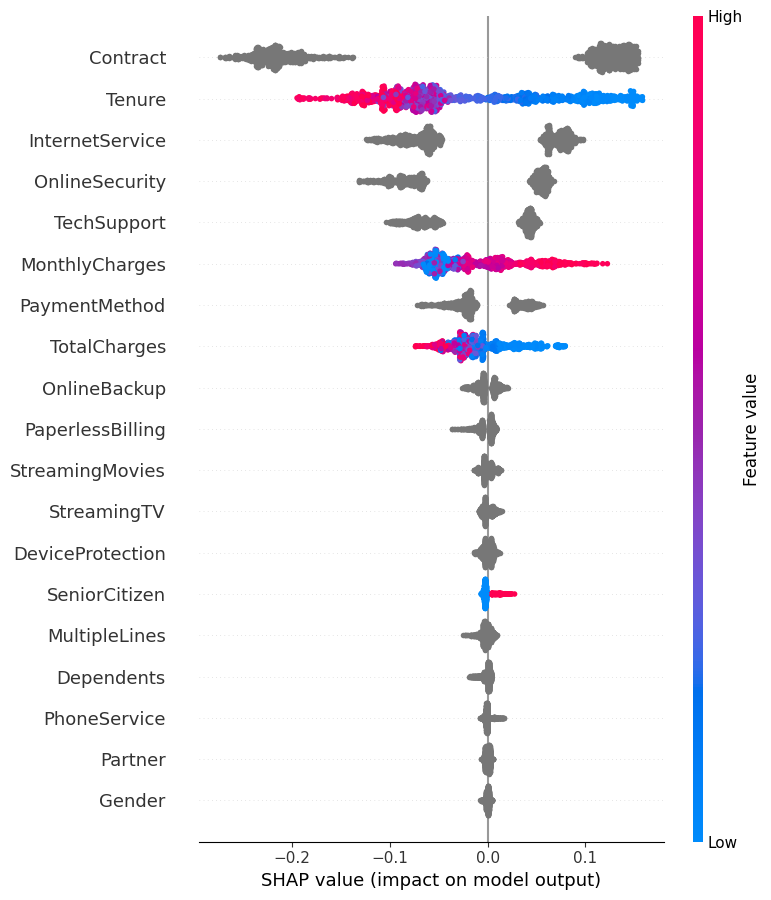

In [48]:
# Summary Plot - ogólny wpływ cech na model
shap.summary_plot(shap_values, X_test)

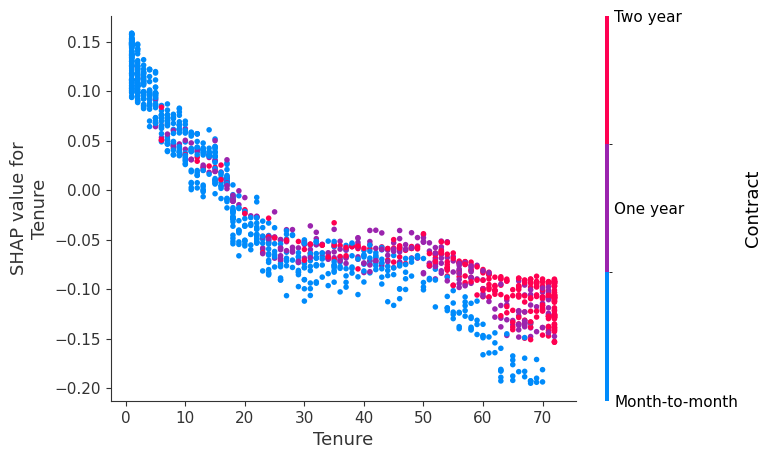

In [61]:
#Feature Dependence Plot - zależność dla wybranej cechy
shap.dependence_plot('Tenure', shap_values, X_test, interaction_index='Contract')




## Analiza pojedynczego klienta

In [70]:
#Obliczanie prawdopodobieństwa dla każdego z klientów

# Prawdopodobieństwo klasy pozytywnej
y_test_proba = final_model.predict_proba(X_test)[:, 1]
X_test_with_probs = X_test.copy()

# Dodanie kolumny z prawdopodobieństwami
X_test_with_probs['Predicted_Probability'] = y_test_proba

# Dodanie przewidywanej klasy na podstawie progu
X_test_with_probs['Predicted_Class'] = (y_test_proba >= threshold).astype(int)

# Dodanie 'Churn'
X_test_with_probs['Churn'] = y_test.values

X_test_with_probs[X_test_with_probs['Predicted_Class'] != X_test_with_probs['Churn']][['Predicted_Probability', 'Predicted_Class', 'Churn']].head(20)

,Predicted_Probability,Predicted_Class,Churn
customerID,,,
6624-JDRDS,0.531722,1,0
3082-VQXNH,0.590482,1,0
9402-ORRAH,0.622499,1,0
2038-OEQZH,0.635028,1,0
5482-VXSXJ,0.573753,1,0
5404-GGUKR,0.582275,1,0
1751-NCDLI,0.602051,1,0
7394-LWLYN,0.635515,1,0
3946-JEWRQ,0.503527,1,0


In [101]:
# Analiza klienta
index = '6624-JDRDS'

In [102]:
X_test.loc[[index], :]

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
customerID,,,,,,,,,,,,,,,,,,,
6624-JDRDS,Female,0,No,No,6,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),29.45,161.45


In [103]:
shap.initjs()

# Zamiana indeksu na pozycję w zbiorze danych
row_position = X_test.index.get_loc(index)

# Force Plot - indywidualny wpływ cech dla rekordu o danym indeksie
shap.force_plot(explainer.expected_value, shap_values[row_position, :],X_test.loc[index, :])


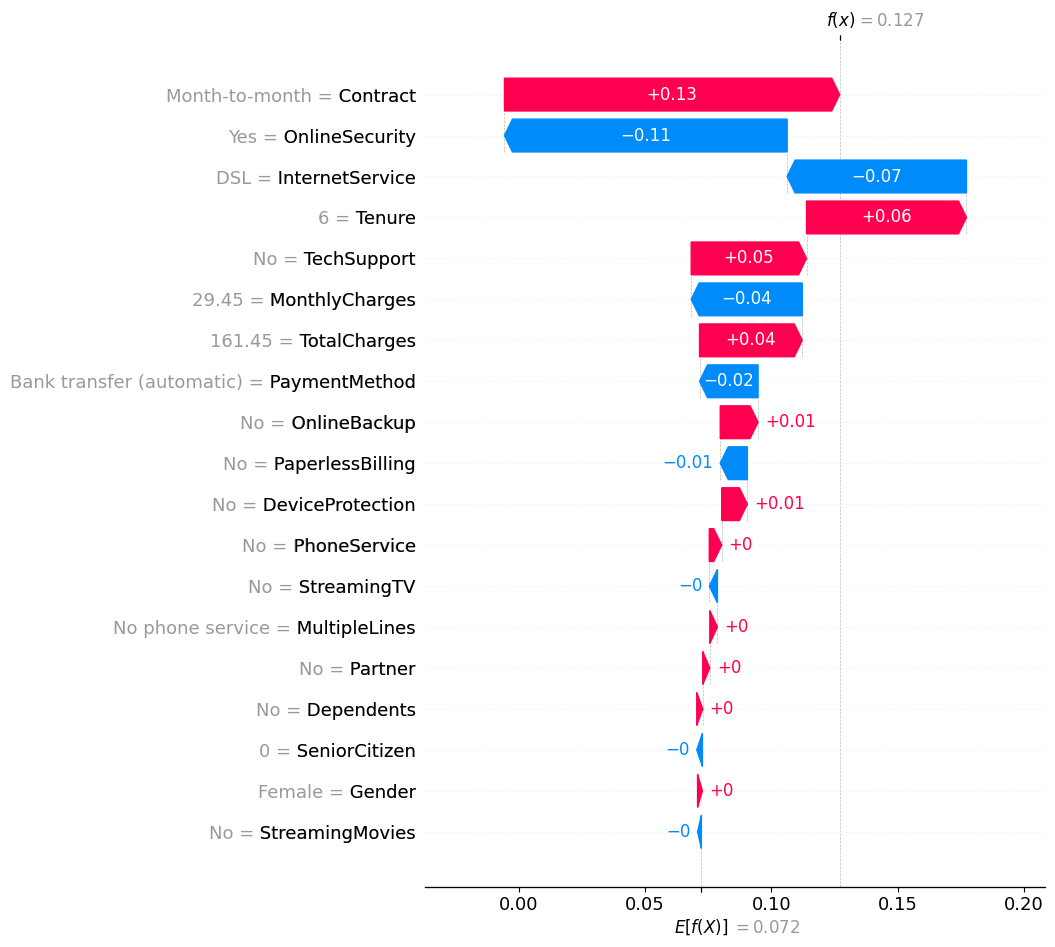

In [104]:
# Waterfall Plot - szczegółowa analiza tego samego rekordu
shap.waterfall_plot(shap.Explanation(values=shap_values[row_position, :], base_values=explainer.expected_value, data=X_test.loc[index, :]), max_display=X_test.shape[1])
